## Analyzing AI Dependency, Career Anxiety, and Student Burnout Among Students

### Importing Required Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/ai_dependency_career_anxiety_students.csv
/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/feature_dictionary.csv
/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/dataset_metadata.json


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

### Dataset Overview

In [3]:
# loading data into dataframes
df = pd.read_csv('/kaggle/input/datasets/sridipbasu/ai-depndency-career-anxiety-and-student-burnout/ai_dependency_career_anxiety_students.csv')

In [4]:
#  dimension
df.shape

(15000, 30)

In [5]:
# first five records
df.head()

,student_id,age,gender,degree_type,stream,year_of_study,college_tier,urban_or_rural,daily_ai_tool_usage_hrs,primary_ai_tools_used,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
0,STU_00001,25,Male,B.Tech/B.E.,Engineering (Non-CS),3,Tier 3,Rural,0.3,Perplexity,...,3.5,8.7,2,1.5,8.5,1,3,6,0.0,9.09
1,STU_00002,20,Female,B.Tech/B.E.,Engineering (Non-CS),4,Tier 3,Urban,1.9,ChatGPT,...,2.4,8.2,3,4.2,8.3,4,5,3,0.0,6.03
2,STU_00003,25,Female,MBA,CS/IT,1,Tier 3,Urban,3.6,Gemini,...,2.3,16.4,1,2.3,7.0,5,9,3,1.0,6.68
3,STU_00004,23,Male,B.Tech/B.E.,CS/IT,1,Tier 1,Urban,4.1,GitHub Copilot,...,7.7,15.0,3,2.6,7.2,6,6,6,0.0,7.71
4,STU_00005,22,Female,MBA,CS/IT,1,Tier 1,Urban,3.4,ChatGPT,...,2.4,1.1,2,1.9,8.0,3,5,4,0.0,4.64


In [6]:
# column info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       15000 non-null  object 
 1   age                              15000 non-null  int64  
 2   gender                           15000 non-null  object 
 3   degree_type                      15000 non-null  object 
 4   stream                           15000 non-null  object 
 5   year_of_study                    15000 non-null  int64  
 6   college_tier                     15000 non-null  object 
 7   urban_or_rural                   15000 non-null  object 
 8   daily_ai_tool_usage_hrs          15000 non-null  float64
 9   primary_ai_tools_used            11785 non-null  object 
 10  uses_ai_for_assignments          15000 non-null  object 
 11  ai_replaces_own_thinking_score   15000 non-null  int64  
 12  ai_dependency_scor

In [7]:
# statistical info
df.describe()

,age,year_of_study,daily_ai_tool_usage_hrs,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,career_clarity_score,internship_experience,weekly_job_application_count,...,daily_study_hours,self_learning_hours_per_week,skill_development_courses_taken,social_media_hrs_per_day,sleep_hours,stress_level,burnout_score,motivation_score,seeks_career_counseling,overall_career_readiness_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,...,15000.000000,14767.000000,15000.0000,14790.000000,14797.000000,15000.000000,15000.000000,15000.000000,14780.000000,15000.000000
mean,21.384533,2.100067,2.013893,2.987733,4.539133,5.913933,3.551200,5.025333,1.718333,10.636133,...,2.730660,6.304612,2.0326,3.006437,6.993364,4.771133,5.472600,4.319733,0.285792,5.998019
std,2.005626,0.987650,1.735977,1.311932,2.315115,2.548207,1.180397,2.200806,1.069583,6.402411,...,1.801026,5.553880,1.8095,1.649033,1.004809,1.778210,2.068317,2.151266,0.451806,1.593982
min,18.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.0000,0.000000,4.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,20.000000,1.000000,0.400000,2.000000,3.000000,4.000000,3.000000,3.000000,1.000000,6.000000,...,1.300000,1.000000,1.0000,1.800000,6.300000,4.000000,4.000000,3.000000,0.000000,4.900000
50%,21.000000,2.000000,1.800000,3.000000,4.000000,6.000000,4.000000,5.000000,2.000000,10.000000,...,2.600000,5.500000,2.0000,3.000000,7.000000,5.000000,5.000000,4.000000,0.000000,6.000000
75%,22.000000,3.000000,3.200000,4.000000,6.000000,8.000000,5.000000,6.000000,2.000000,15.000000,...,4.000000,10.100000,3.0000,4.100000,7.700000,6.000000,7.000000,6.000000,1.000000,7.120000
max,28.000000,4.000000,8.000000,5.000000,10.000000,10.000000,5.000000,10.000000,4.000000,35.000000,...,10.300000,31.000000,10.0000,8.000000,10.000000,10.000000,10.000000,10.000000,1.000000,10.000000


In [8]:
# null values per column
df.isnull().sum()

student_id                            0
age                                   0
gender                                0
degree_type                           0
stream                                0
year_of_study                         0
college_tier                          0
urban_or_rural                        0
daily_ai_tool_usage_hrs               0
primary_ai_tools_used              3215
uses_ai_for_assignments               0
ai_replaces_own_thinking_score        0
ai_dependency_score                   0
placement_anxiety_score               0
fear_of_job_loss_to_ai                0
career_clarity_score                  0
internship_experience                 0
weekly_job_application_count          0
resume_confidence_score               0
interview_anxiety_score               0
daily_study_hours                     0
self_learning_hours_per_week        233
skill_development_courses_taken       0
social_media_hrs_per_day            210
sleep_hours                         203


In [9]:
# unique values 
df['primary_ai_tools_used'].unique()

array(['Perplexity', 'ChatGPT', 'Gemini', 'GitHub Copilot', nan, 'Claude'],
      dtype=object)

In [10]:
df['stream'].unique()

array(['Engineering (Non-CS)', 'CS/IT', 'Arts/Sciences',
       'Commerce/Management'], dtype=object)

In [11]:
# mode of primary_tools_used
df['primary_ai_tools_used'].mode()[0]

'ChatGPT'

### Visualizing Distribution

In [12]:
# columns in df
df.columns

Index(['student_id', 'age', 'gender', 'degree_type', 'stream', 'year_of_study',
       'college_tier', 'urban_or_rural', 'daily_ai_tool_usage_hrs',
       'primary_ai_tools_used', 'uses_ai_for_assignments',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score'],
      dtype='object')

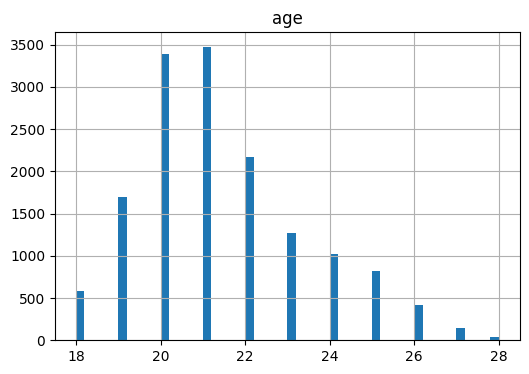

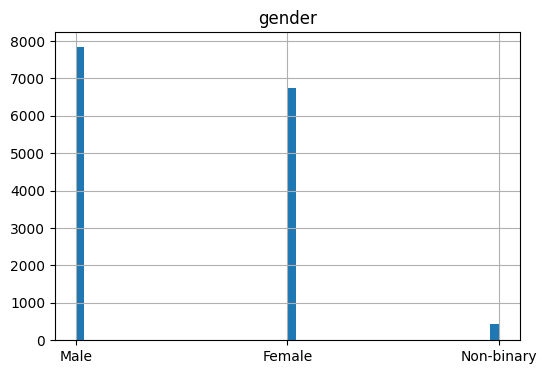

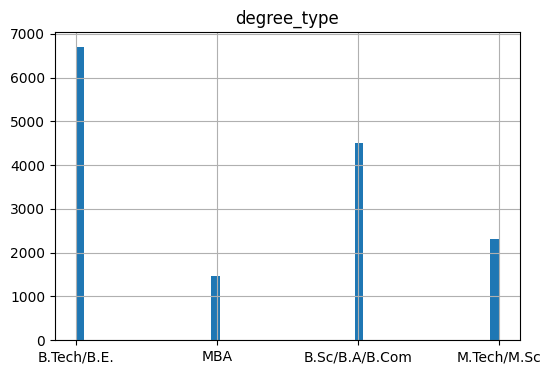

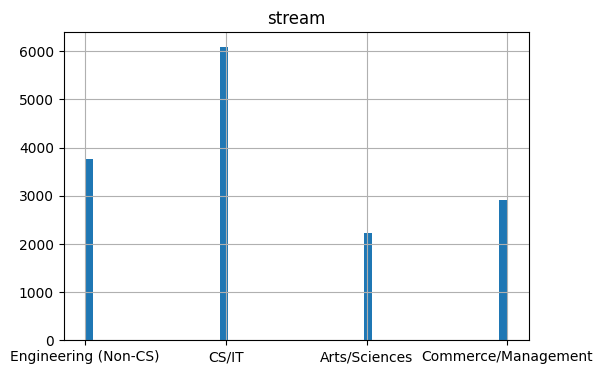

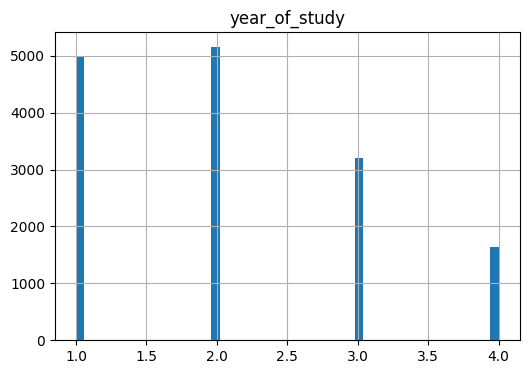

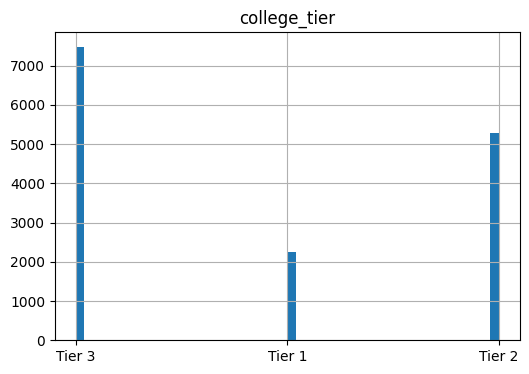

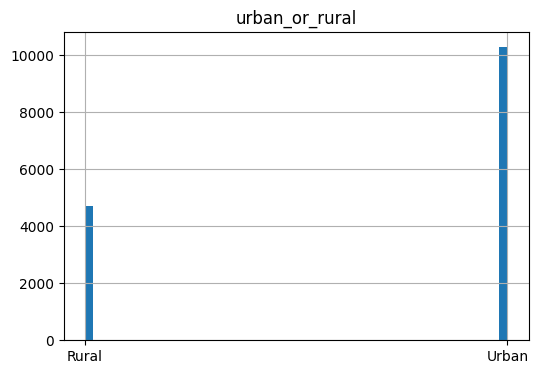

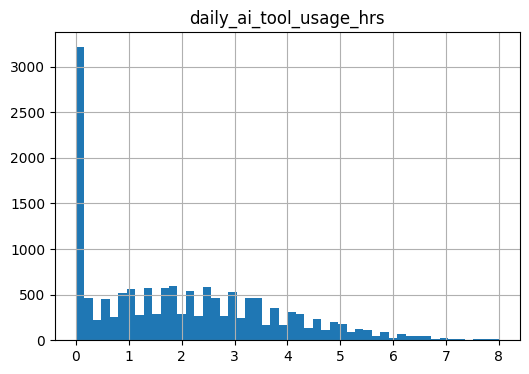

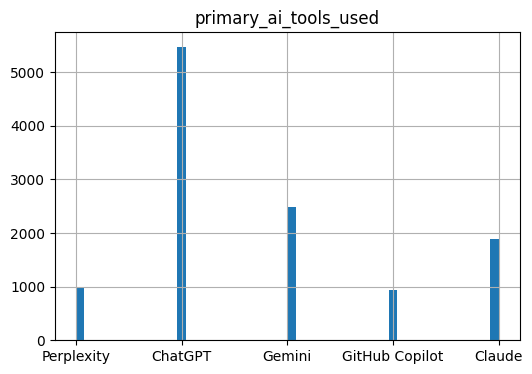

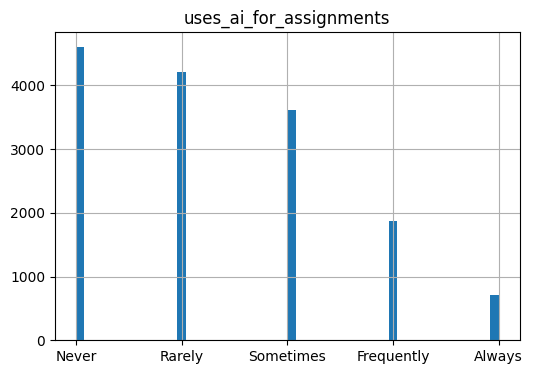

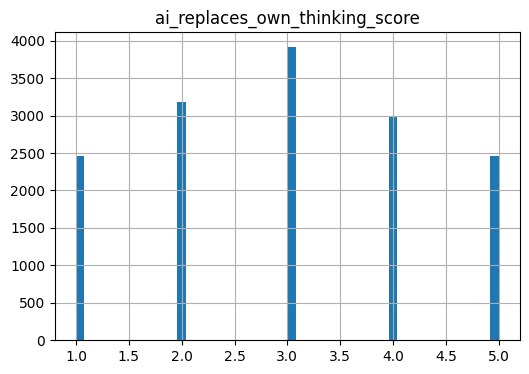

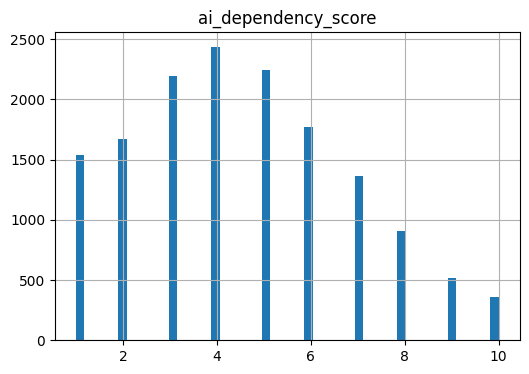

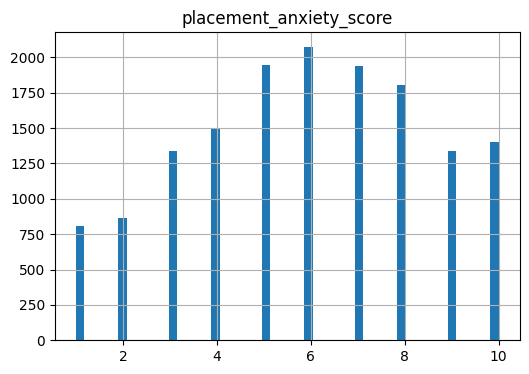

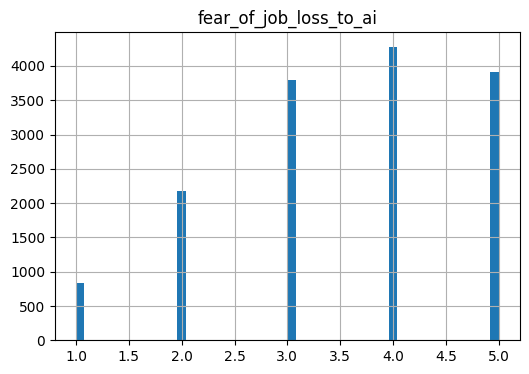

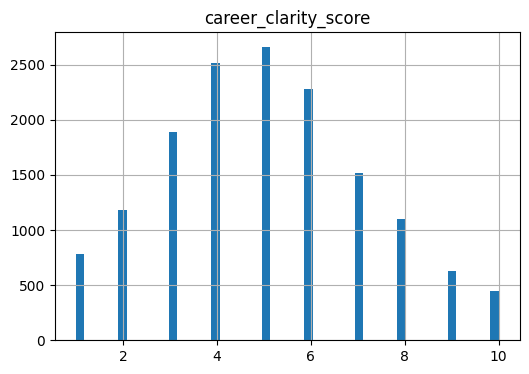

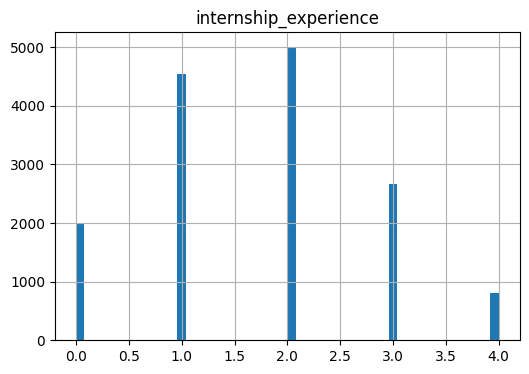

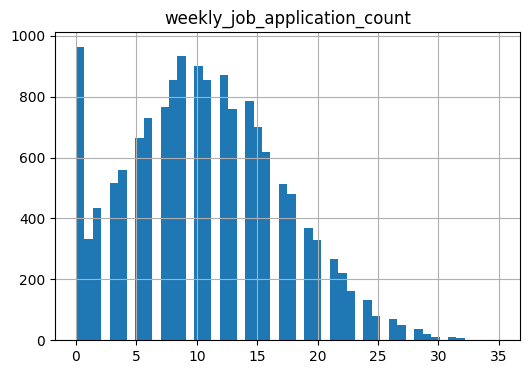

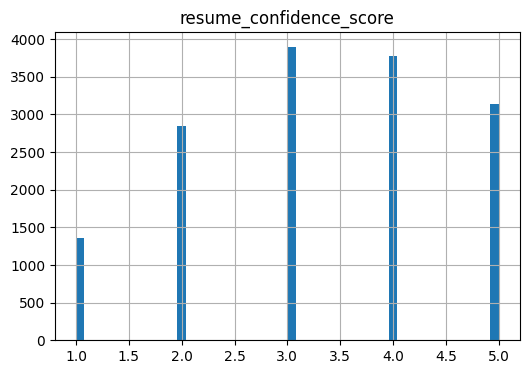

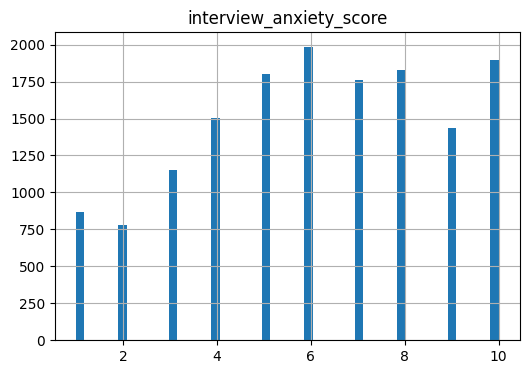

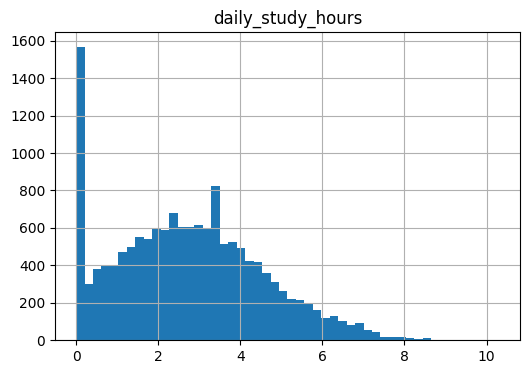

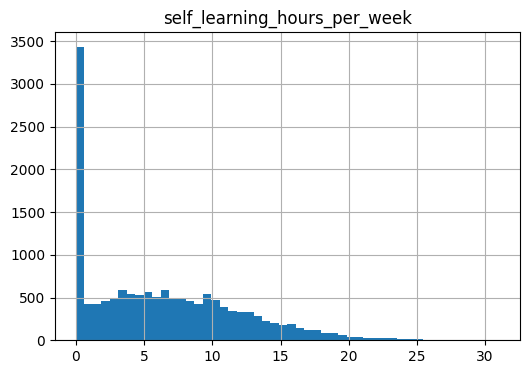

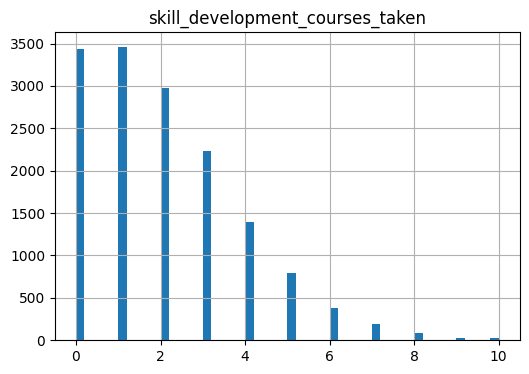

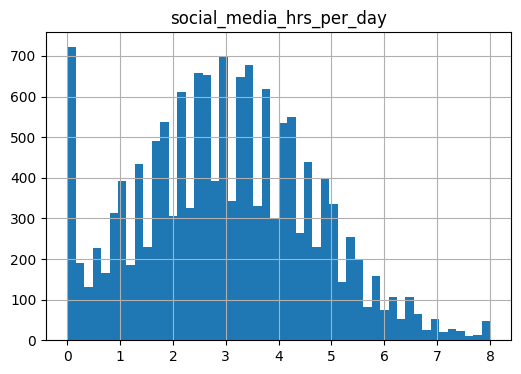

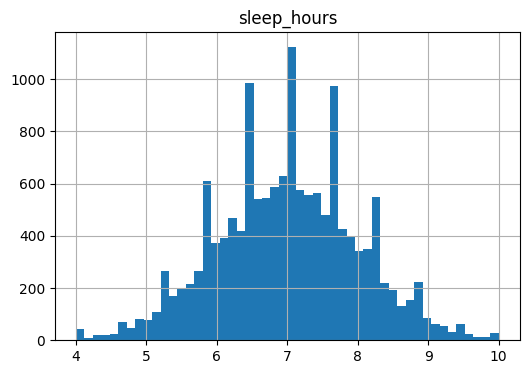

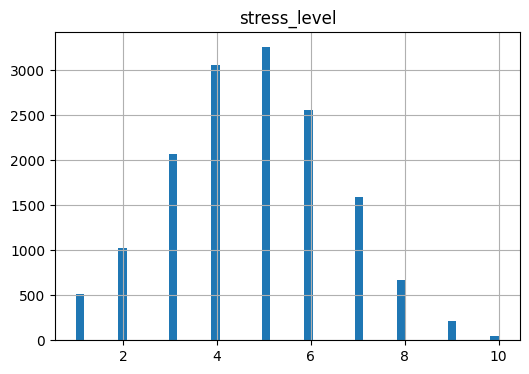

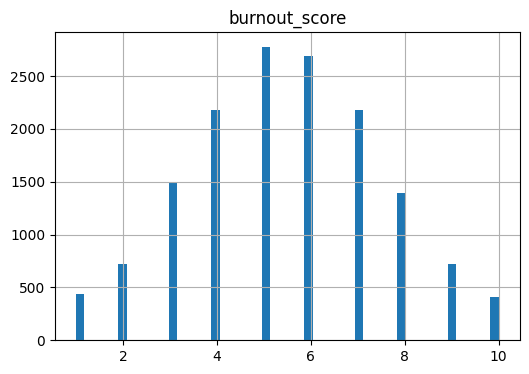

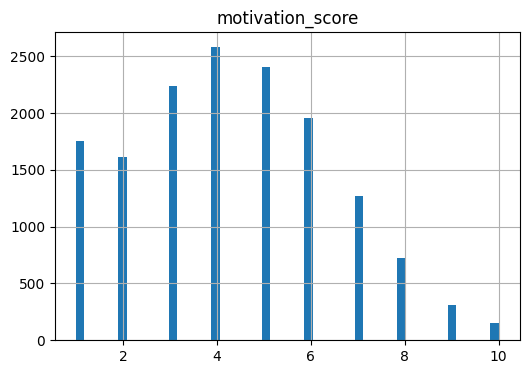

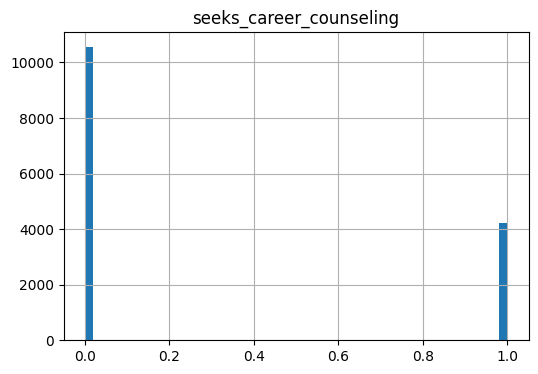

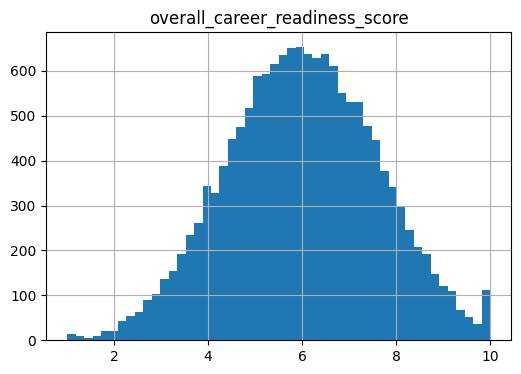

In [13]:
# visualizing distributions for each col in df
for col in df.columns[1:]:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=50)
    plt.title(col)
    plt.show()

In [14]:
processed_df = df.copy()

### Handling Missing Values 

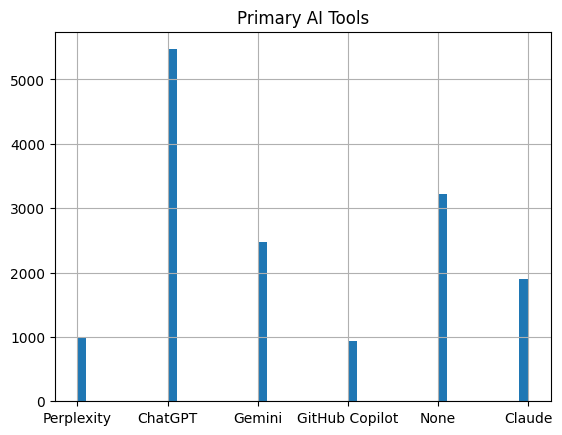

In [15]:
# replacing missing values with 'None' in 'primary_ai_tools_used'
processed_df['primary_ai_tools_used'] = processed_df['primary_ai_tools_used'].fillna('None')

processed_df['primary_ai_tools_used'].hist(bins=50)
plt.title('Primary AI Tools')
plt.show()

In [16]:
# replacing missing values with median in 'self_learning_hours_per_week','social_media_hrs_per_day' and 'sleep_hours'
num_cols = [
    'self_learning_hours_per_week',
    'social_media_hrs_per_day',
    'sleep_hours'
]

for col in num_cols:
    processed_df[col] = processed_df[col].fillna(processed_df[col].median())

In [17]:
# replacing missing values with mode in 'seeks_career_counseling'
processed_df['seeks_career_counseling'] = processed_df['seeks_career_counseling'].fillna(processed_df['seeks_career_counseling'].mode()[0])

In [18]:
processed_df.isnull().sum()

student_id                         0
age                                0
gender                             0
degree_type                        0
stream                             0
year_of_study                      0
college_tier                       0
urban_or_rural                     0
daily_ai_tool_usage_hrs            0
primary_ai_tools_used              0
uses_ai_for_assignments            0
ai_replaces_own_thinking_score     0
ai_dependency_score                0
placement_anxiety_score            0
fear_of_job_loss_to_ai             0
career_clarity_score               0
internship_experience              0
weekly_job_application_count       0
resume_confidence_score            0
interview_anxiety_score            0
daily_study_hours                  0
self_learning_hours_per_week       0
skill_development_courses_taken    0
social_media_hrs_per_day           0
sleep_hours                        0
stress_level                       0
burnout_score                      0
m

### Encoding

In [19]:
# one-hot encoding
processed_df = pd.get_dummies(df, columns=['primary_ai_tools_used','gender','degree_type','stream','urban_or_rural'], drop_first=False)

processed_df.head()

,student_id,age,year_of_study,college_tier,daily_ai_tool_usage_hrs,uses_ai_for_assignments,ai_replaces_own_thinking_score,ai_dependency_score,placement_anxiety_score,fear_of_job_loss_to_ai,...,degree_type_B.Sc/B.A/B.Com,degree_type_B.Tech/B.E.,degree_type_M.Tech/M.Sc,degree_type_MBA,stream_Arts/Sciences,stream_CS/IT,stream_Commerce/Management,stream_Engineering (Non-CS),urban_or_rural_Rural,urban_or_rural_Urban
0,STU_00001,25,3,Tier 3,0.3,Never,1,1,3,2,...,False,True,False,False,False,False,False,True,True,False
1,STU_00002,20,4,Tier 3,1.9,Rarely,3,7,5,3,...,False,True,False,False,False,False,False,True,False,True
2,STU_00003,25,1,Tier 3,3.6,Sometimes,4,7,6,3,...,False,False,False,True,False,True,False,False,False,True
3,STU_00004,23,1,Tier 1,4.1,Frequently,4,4,3,4,...,False,True,False,False,False,True,False,False,False,True
4,STU_00005,22,1,Tier 1,3.4,Sometimes,4,10,8,5,...,False,False,False,True,False,True,False,False,False,True


In [20]:
# ordinal encoding 'uses_ai_for_assignments'
encoder = OrdinalEncoder(categories=[['Never', 'Rarely', 'Sometimes', 'Frequently', 'Always']], dtype=int)
processed_df['uses_ai_for_assignments_ord'] = encoder.fit_transform(processed_df[['uses_ai_for_assignments']])

processed_df[['uses_ai_for_assignments', 'uses_ai_for_assignments_ord']].head()

,uses_ai_for_assignments,uses_ai_for_assignments_ord
0,Never,0
1,Rarely,1
2,Sometimes,2
3,Frequently,3
4,Sometimes,2


In [21]:
# ordinal encoding 'college_tier'
encoder = OrdinalEncoder(categories=[['Tier 3', 'Tier 2', 'Tier 1']], dtype=int)
processed_df['college_tier_ord'] = encoder.fit_transform(processed_df[['college_tier']])

processed_df[['college_tier', 'college_tier_ord']].head()

,college_tier,college_tier_ord
0,Tier 3,0
1,Tier 3,0
2,Tier 3,0
3,Tier 1,2
4,Tier 1,2


In [22]:
# generating new col 'non_CS/IT' by adding 'stream_Arts/Sciences', 'stream_Commerce/Management' and 'stream_Engineering (Non-CS)'
processed_df['non_CS/IT'] = processed_df['stream_Arts/Sciences'] + processed_df['stream_Commerce/Management'] + processed_df['stream_Engineering (Non-CS)']
processed_df['CS/IT'] = processed_df['stream_CS/IT']
processed_df[['non_CS/IT', 'CS/IT']].head()

,non_CS/IT,CS/IT
0,True,False
1,True,False
2,False,True
3,False,True
4,False,True


In [23]:
processed_df['Urban'] = processed_df['urban_or_rural_Urban']
processed_df['Urban'].head()

0    False
1     True
2     True
3     True
4     True
Name: Urban, dtype: bool

In [24]:
processed_df.columns

Index(['student_id', 'age', 'year_of_study', 'college_tier',
       'daily_ai_tool_usage_hrs', 'uses_ai_for_assignments',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score', 'primary_ai_tools_used_ChatGPT',
       'primary_ai_tools_used_Claude', 'primary_ai_tools_used_Gemini',
       'primary_ai_tools_used_GitHub Copilot',
       'primary_ai_tools_used_Perplexity', 'gender_Female', 'gender_Male',
       'gender_Non-binary', 'degree_type_B.Sc/B.A/B.Com',
       'degree_type_B.Tech/B.E.', 'degree

### Skew Analysis

In [25]:
# calculating skew coefficients for each col in processed_df
cols = ['age', 'year_of_study','daily_ai_tool_usage_hrs',
       'ai_replaces_own_thinking_score', 'ai_dependency_score',
       'placement_anxiety_score', 'fear_of_job_loss_to_ai',
       'career_clarity_score', 'internship_experience',
       'weekly_job_application_count', 'resume_confidence_score',
       'interview_anxiety_score', 'daily_study_hours',
       'self_learning_hours_per_week', 'skill_development_courses_taken',
       'social_media_hrs_per_day', 'sleep_hours', 'stress_level',
       'burnout_score', 'motivation_score', 'seeks_career_counseling',
       'overall_career_readiness_score', 'primary_ai_tools_used_ChatGPT',
       'primary_ai_tools_used_Claude', 'primary_ai_tools_used_Gemini',
       'primary_ai_tools_used_GitHub Copilot',
       'primary_ai_tools_used_Perplexity', 'gender_Female', 'gender_Male', 'degree_type_B.Sc/B.A/B.Com',
       'degree_type_B.Tech/B.E.', 'degree_type_M.Tech/M.Sc','non_CS/IT', 'CS/IT', 'Urban',
       'uses_ai_for_assignments_ord', 'college_tier_ord']
for col in cols:
    skew = processed_df[col].skew()
    print(col,skew)

age 0.7190580948307155
year_of_study 0.48198495717930184
daily_ai_tool_usage_hrs 0.6648067580306194
ai_replaces_own_thinking_score 0.022444120151504706
ai_dependency_score 0.34536004446850316
placement_anxiety_score -0.15722286917767936
fear_of_job_loss_to_ai -0.4177522491358103
career_clarity_score 0.21678771488594517
internship_experience 0.19658972343863473
weekly_job_application_count 0.30924504579818957
resume_confidence_score -0.21117362867168202
interview_anxiety_score -0.21875382057669132
daily_study_hours 0.3863985007297501
self_learning_hours_per_week 0.7093860592075928
skill_development_courses_taken 0.9968130625920453
social_media_hrs_per_day 0.1988647866126021
sleep_hours -0.014885175360404507
stress_level 0.06945084869239969
burnout_score 0.009698157762714057
motivation_score 0.2749679315050294
seeks_career_counseling 0.9483602446610647
overall_career_readiness_score -0.02915315030962347
primary_ai_tools_used_ChatGPT 0.5626782854431052
primary_ai_tools_used_Claude 2.25152

Key findings from skew coefficient -
* mostly undergraduate urban students
* largely engineering/CS-oriented
* moderate AI adoption overall
* heavy AI usage concentrated in a smaller advanced subgroup
* strong concern about AI affecting careers
* uneven career preparation/upskilling behavior
* niche adoption of advanced AI tools like Copilot and Perplexity
* relatively balanced stress/burnout distributions

### Correlation Analysis

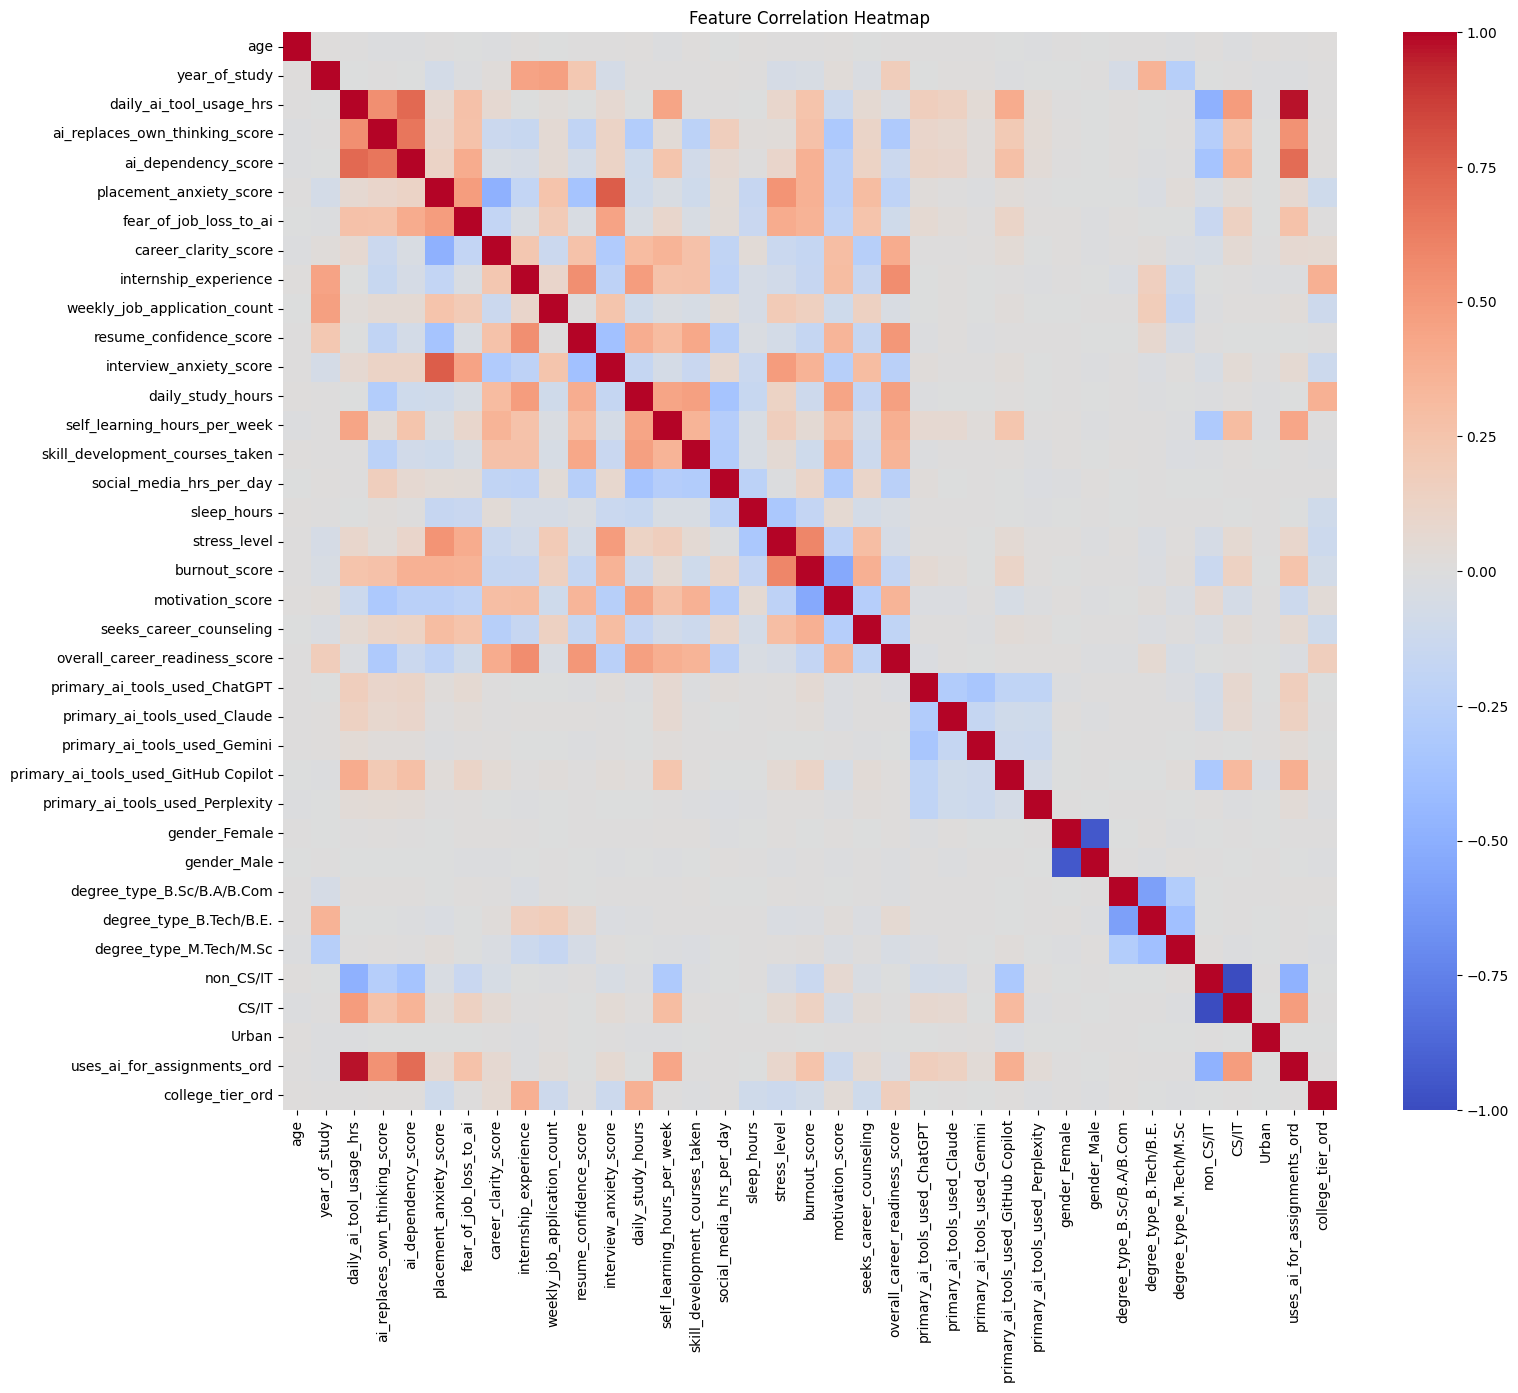

In [26]:
# creating new analysis_df
analysis_df = processed_df[cols]

# correlation matrix for processed_df
corr = analysis_df.corr()

# visualizing feature correlation heatmap
plt.figure(figsize=(17,14))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

### Key Findings from Correlation Heatmap Analysis

#### Positive Correlations

##### 1. AI Usage, Dependency, and Psychological Stress Indicators
A positive correlation is observed between:
- `daily_ai_tool_usage_hrs`
- `ai_replaces_own_thinking_score`
- `ai_dependency_score`
- `fear_of_job_loss_to_ai`
- `uses_ai_for_assignments`
- `burnout_score`
- `interview_anxiety_score`
- `stress_level`
- `seeks_career_counseling`
- `CS/IT`

This suggests that students with higher AI usage also tend to:
- rely more on AI tools,
- feel greater fear regarding AI-driven job replacement,
- experience increased stress, burnout, and interview anxiety,
- and are more likely to seek career counseling.

The correlation with `CS/IT` indicates stronger AI adoption among students from technical backgrounds.

---

##### 2. Academic Progress and Career Preparedness
Positive relationships are observed between:
- `year_of_study`
- `internship_experience`
- `weekly_job_application_count`
- `resume_confidence_score`
- `overall_career_readiness_score`
- `degree_type_B.Tech/B.E`

This suggests that students in later years of study, particularly from engineering backgrounds, tend to:
- apply for more jobs,
- possess greater internship exposure,
- have higher resume confidence,
- and demonstrate stronger career readiness.

---

##### 3. Internship Experience and College Tier
A positive correlation exists between:
- `internship_experience`
- `college_tier`

This may indicate that students from higher-tier colleges receive greater internship opportunities and industry exposure.

---

##### 4. Self-Development and Career Readiness Cluster
Positive relationships are observed between:
- `career_clarity_score`
- `internship_experience`
- `resume_confidence_score`
- `daily_study_hours`
- `self_learning_hours_per_week`
- `skill_development_courses_taken`
- `motivation_score`
- `overall_career_readiness_score`

This suggests that proactive academic and self-development behaviors are strongly associated with:
- improved career clarity,
- higher confidence,
- increased motivation,
- and stronger career preparedness.

---

##### 5. Urban Background and AI Usage
A mild positive correlation is observed between:
- `Urban`
- AI usage-related variables

This may suggest greater accessibility, exposure, and adoption of AI technologies among urban students.

---

### Negative Correlations

##### 1. AI Usage and Non-CS/IT Background
Negative correlations are observed between:
- `daily_ai_tool_usage_hrs`
- `ai_replaces_own_thinking_score`
- `ai_dependency_score`
- `fear_of_job_loss_to_ai`
- `uses_ai_for_assignments`
- `burnout_score`
- `interview_anxiety_score`
- `stress_level`

and:
- `non_CS/IT`

This suggests that non-technical students generally exhibit lower AI usage and lower AI dependency compared to CS/IT students.

---

##### 2. AI Usage vs Motivation and Career Readiness
Negative relationships are observed between:
- AI usage-related variables

and:
- `motivation_score`
- `overall_career_readiness_score`

This may indicate that excessive dependence on AI tools could be associated with lower self-motivation and reduced confidence in career preparedness.

---

##### 3. Productive Learning Habits vs Social Media Usage
Negative correlations are observed between:
- `daily_study_hours`
- `self_learning_hours_per_week`
- `skill_development_courses_taken`
- `motivation_score`

and:
- `social_media_hrs_per_day`

This suggests that increased social media usage may be associated with reduced study time, lower self-learning engagement, and decreased motivation.

---

##### 4. Sleep and Stress
A negative correlation exists between:
- `sleep_hours`
- `stress_level`

This indicates that students with lower sleep duration tend to report higher stress levels.

---

##### 5. AI Dependency and Motivation
Negative relationships are observed between:
- `daily_ai_tool_usage_hrs`
- `ai_replaces_own_thinking_score`
- `ai_dependency_score`
- `fear_of_job_loss_to_ai`
- `uses_ai_for_assignments`
- `burnout_score`

and:
- `motivation_score`

This may suggest that higher AI dependency and burnout are associated with reduced academic motivation.

---

##### 6. One-Hot Encoded Variables
Strong positive and negative correlations observed among:
- `gender_*`
- `primary_ai_tools_*`
- `degree_type_*`
- `CS/IT`
- `non_CS/IT`

are expected because these variables are one-hot encoded representations of mutually exclusive categories. These correlations do not indicate meaningful behavioral relationships.
```


### Summary of Key Findings
The correlation analysis suggests that higher AI usage and dependency are associated with increased stress, burnout, interview anxiety, and fear of job loss, particularly among CS/IT students, while proactive behaviors such as self-learning, internships, and skill development are positively linked with motivation and career readiness. Additionally, higher social media usage and lower sleep hours appear negatively associated with productivity, motivation, and stress management.

In [27]:
# sorted correlation of 'overall_career_readiness_score' with all cols in analysis_df in ascending order
analysis_df.corr(numeric_only=True)[
    'overall_career_readiness_score'
].sort_values(ascending=False)

overall_career_readiness_score          1.000000
internship_experience                   0.557186
resume_confidence_score                 0.510668
daily_study_hours                       0.468598
career_clarity_score                    0.404427
self_learning_hours_per_week            0.386007
skill_development_courses_taken         0.357716
motivation_score                        0.353868
year_of_study                           0.179215
college_tier_ord                        0.164516
degree_type_B.Tech/B.E.                 0.058336
gender_Female                           0.009303
primary_ai_tools_used_Perplexity        0.009295
primary_ai_tools_used_GitHub Copilot    0.008266
age                                     0.005659
CS/IT                                   0.004764
primary_ai_tools_used_Claude            0.000474
Urban                                  -0.001148
non_CS/IT                              -0.004764
primary_ai_tools_used_Gemini           -0.004914
gender_Male         

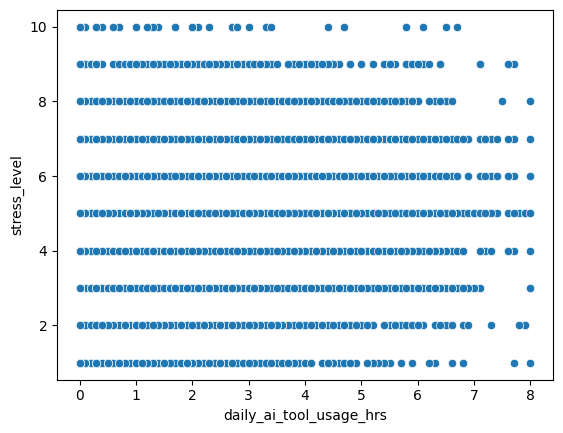

In [28]:
sns.scatterplot(analysis_df, x='daily_ai_tool_usage_hrs', y='stress_level')
plt.show()

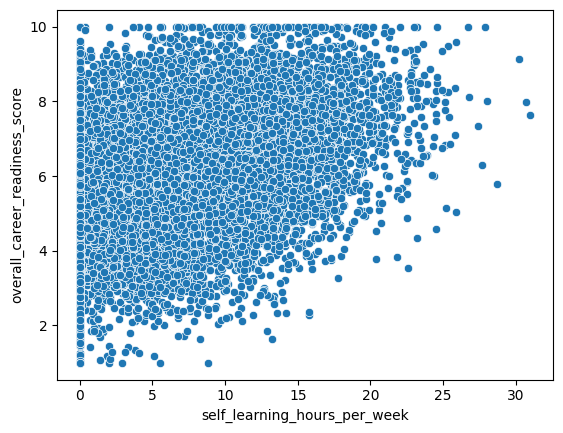

In [29]:
sns.scatterplot(analysis_df, x='self_learning_hours_per_week', y='overall_career_readiness_score')
plt.show()

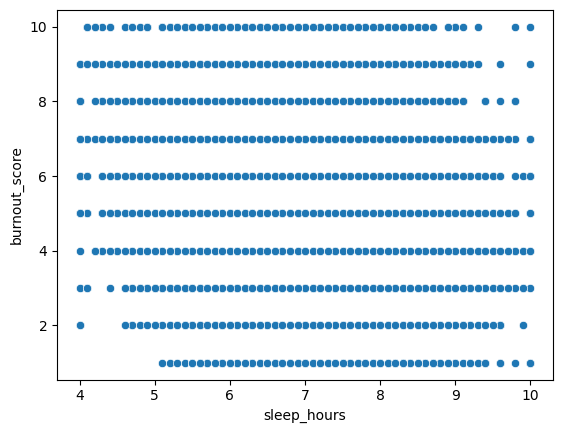

In [30]:
sns.scatterplot(analysis_df, x='sleep_hours', y='burnout_score')
plt.show()

### Conclusion



Students with higher AI usage tend to exhibit increased stress, burnout, and interview anxiety, suggesting a possible association between AI dependency and psychological pressure.

### Future Enhancements

- Build machine learning models to predict student career readiness, stress levels, and burnout scores.
- Apply feature importance and SHAP analysis to identify the most influential factors affecting student anxiety and AI dependency.
- Perform statistical hypothesis testing to validate observed correlations and behavioral patterns.
- Expand the dataset with larger and more diverse student populations for better generalization.
- Incorporate time-series or longitudinal data to analyze how AI dependency and career anxiety evolve over time.
- Develop interactive dashboards for visual exploration of student behavioral and career trends.
- Compare AI usage patterns across different academic backgrounds, regions, and education levels.
- Explore clustering techniques to identify distinct student behavioral and learning profiles.